# Machine Learning e Visão Computacional [T3] #
## Situação de Aprendizagem (Projeto Avaliativo) - Módulo 1 - Semana 14 ##

### Aluno: Henrique Tamaki ###

### OPÇÃO B: E-commerce Churn (Setor de Varejo) ###

O Problema: Um aplicativo de vendas precisa prever quais clientes estão prestes a abandonar a plataforma (alvo: Churn = 1) para oferecer cupons preventivos de retenção.

Desafio de Negócio: O que custa mais caro para o aplicativo: dar um cupom de desconto para quem já ia continuar comprando normalmente (Falso Positivo) ou perder um cliente em definitivo sem tentar retê-lo (Falso Negativo)?

Dataset original: https://drive.google.com/file/d/1Nbmt6Y_P1TjdFxsfTxfKQxKLkaNDJrT9/view?usp=sharing


Baixado e salvo em: dados/E Commerce Dataset - E Comm.csv

## Fase 1: Análise Exploratória de Dados (EDA)

## Descritiva e Estatística: ##

Exiba o tamanho total da base (linhas e colunas), os tipos de dados de cada variável e o sumário estatístico descritivo (médias, mínimos, máximos e quartis via .describe()) e etc.

In [90]:
# importacao bibliotecas usadas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)



sns.set_style("whitegrid")

In [91]:
# Tamanho da base e tipos de dados de cada variável
df = pd.read_csv("dados/E Commerce Dataset - E Comm.csv")

print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")


Linhas: 5630 | Colunas: 20


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [93]:
# Sumário estatístico descritivo (médias, mínimos, máximos, quartis)

print("Sumário estatístico descritivo")

display(df.describe())          # variáveis numéricas
display(df.describe(include="str"))  # variáveis categóricas

Sumário estatístico descritivo


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


In [56]:
# Duplicados 
print(f"Linhas duplicadas: {df.duplicated().sum()}")


Linhas duplicadas: 0


In [57]:
# Checagem sem CustomerID
print(f"Linhas duplicadas (excluindo CustomerID): {df.drop(columns='CustomerID').duplicated().sum()}")

Linhas duplicadas (excluindo CustomerID): 556


Há valores duplicados, 614 linhas (10.90%) quando analisamos os dados puro, sem o customerID. Eu entendo que não são duplicados mas dados corretos pois são situações de compra então devemos manter os dados e analisar eles como dados corretos.

In [95]:
# Valores nulos
print("Colunas e quantidades de nulos")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
percentual = (nulos / len(df) * 100).round(2)
pd.DataFrame({"qtd_nulos": nulos, "percentual (%)": percentual})

Colunas e quantidades de nulos


,qtd_nulos,percentual (%)
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


Em um banco de dados de e-commerce, o termo `Tenure` refere-se ao tempo de vida ou tempo de relacionamento do cliente com a plataforma. É o período decorrido desde o momento em que o usuário realizou o seu cadastro (ou fez a sua primeira compra) até a data atual ou a data de sua última atividade.

### Visual: Plote no mínimo 3 gráficos explicativos ###

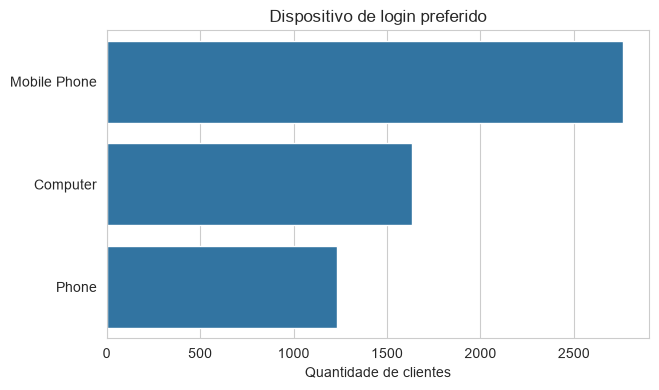

In [96]:
# Gráfico 1 - Barras: dispositivo de login preferido
plt.figure(figsize=(7, 4))
sns.countplot(y="PreferredLoginDevice", data=df, order=df["PreferredLoginDevice"].value_counts().index)
plt.title("Dispositivo de login preferido")
plt.xlabel("Quantidade de clientes")
plt.ylabel("")
plt.show()

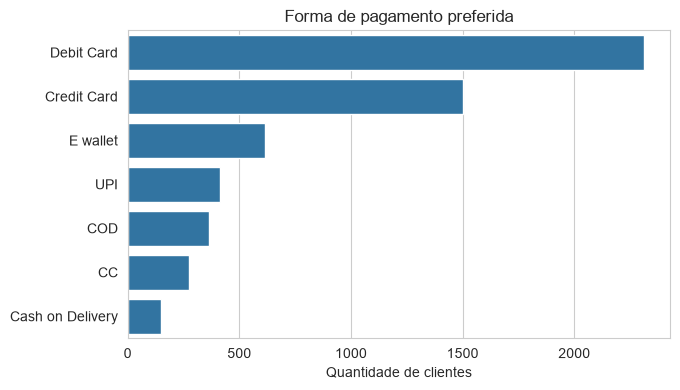

In [97]:
# Gráfico 2 - Barras: forma de pagamento preferida
plt.figure(figsize=(7, 4))
sns.countplot(y="PreferredPaymentMode", data=df, order=df["PreferredPaymentMode"].value_counts().index)
plt.title("Forma de pagamento preferida")
plt.xlabel("Quantidade de clientes")
plt.ylabel("")
plt.show()

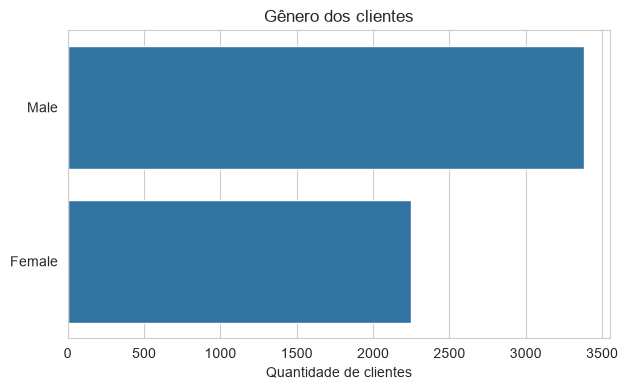

In [98]:
# Gráfico 3 - Barras: gênero
plt.figure(figsize=(7, 4))
sns.countplot(y="Gender", data=df, order=df["Gender"].value_counts().index)
plt.title("Gênero dos clientes")
plt.xlabel("Quantidade de clientes")
plt.ylabel("")
plt.show()

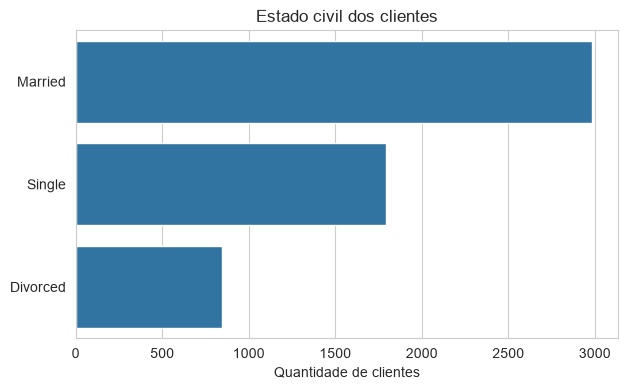

In [99]:
# Gráfico 4 - Barras: estado civil
plt.figure(figsize=(7, 4))
sns.countplot(y="MaritalStatus", data=df, order=df["MaritalStatus"].value_counts().index)
plt.title("Estado civil dos clientes")
plt.xlabel("Quantidade de clientes")
plt.ylabel("")
plt.show()

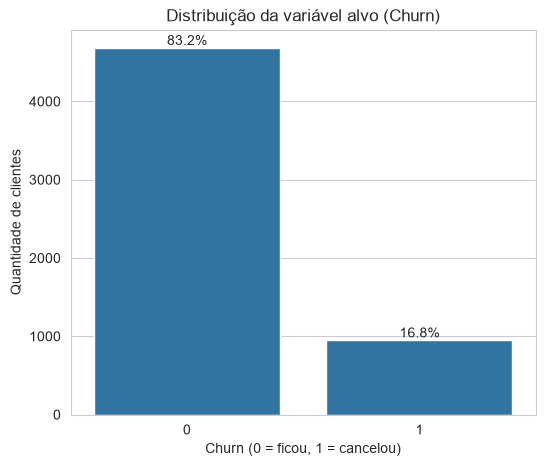

In [100]:
# Gráfico 5 - Barras: desbalanceamento da variável alvo (Churn)
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="Churn", data=df)
plt.title("Distribuição da variável alvo (Churn)")
plt.xlabel("Churn (0 = ficou, 1 = cancelou)")
plt.ylabel("Quantidade de clientes")

total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()


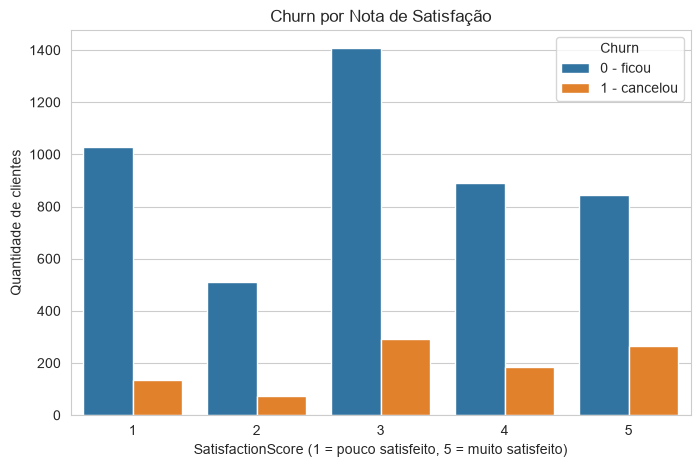

In [101]:
# Gráfico 6 - Barras: Churn por nível de satisfação (SatisfactionScore)
plt.figure(figsize=(8, 5))
sns.countplot(x="SatisfactionScore", hue="Churn", data=df)
plt.title("Churn por Nota de Satisfação")
plt.xlabel("SatisfactionScore (1 = pouco satisfeito, 5 = muito satisfeito)")
plt.ylabel("Quantidade de clientes")
plt.legend(title="Churn", labels=["0 - ficou", "1 - cancelou"])
plt.show()

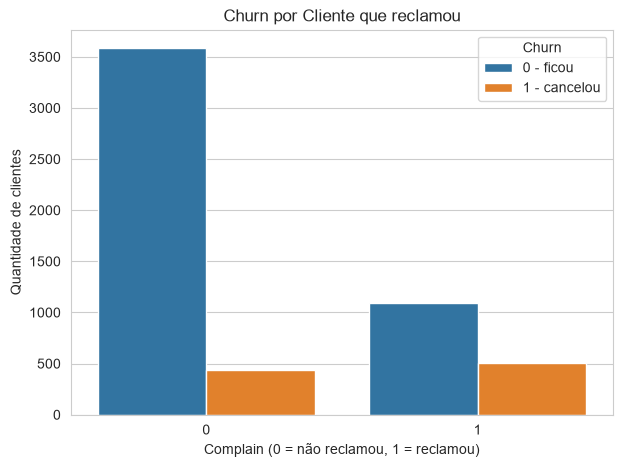

In [102]:
# Gráfico 7 - Barras: Churn por reclamação registrada (Complain)
plt.figure(figsize=(7, 5))
sns.countplot(x="Complain", hue="Churn", data=df)
plt.title("Churn por Cliente que reclamou")
plt.xlabel("Complain (0 = não reclamou, 1 = reclamou)")
plt.ylabel("Quantidade de clientes")
plt.legend(title="Churn", labels=["0 - ficou", "1 - cancelou"])
plt.show()

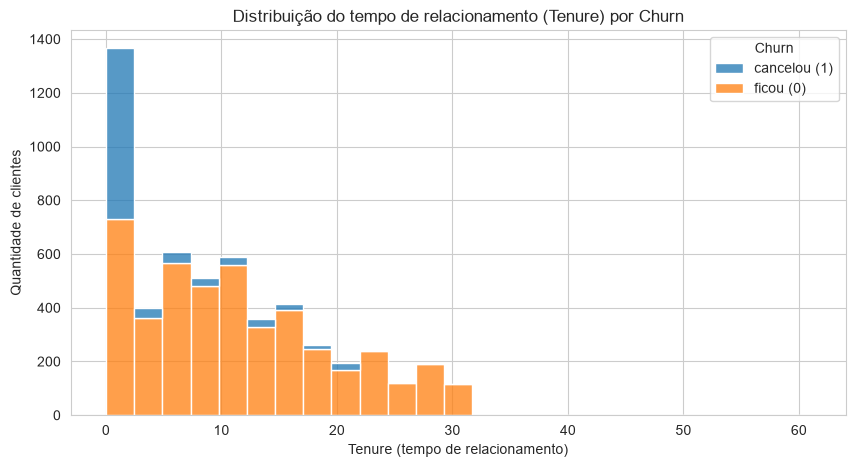

In [106]:
# Gráfico 8 - Histograma: distribuição do Tenure por Churn
plt.figure(figsize=(10, 5))
sns.histplot(
    x=df["Tenure"],
    hue=df["Churn"].map({0: "ficou (0)", 1: "cancelou (1)"}),
    bins=25,
    multiple="stack",
)
plt.title("Distribuição do tempo de relacionamento (Tenure) por Churn")
plt.xlabel("Tenure (tempo de relacionamento)")
plt.ylabel("Quantidade de clientes")
plt.gca().get_legend().set_title("Churn")
plt.show()


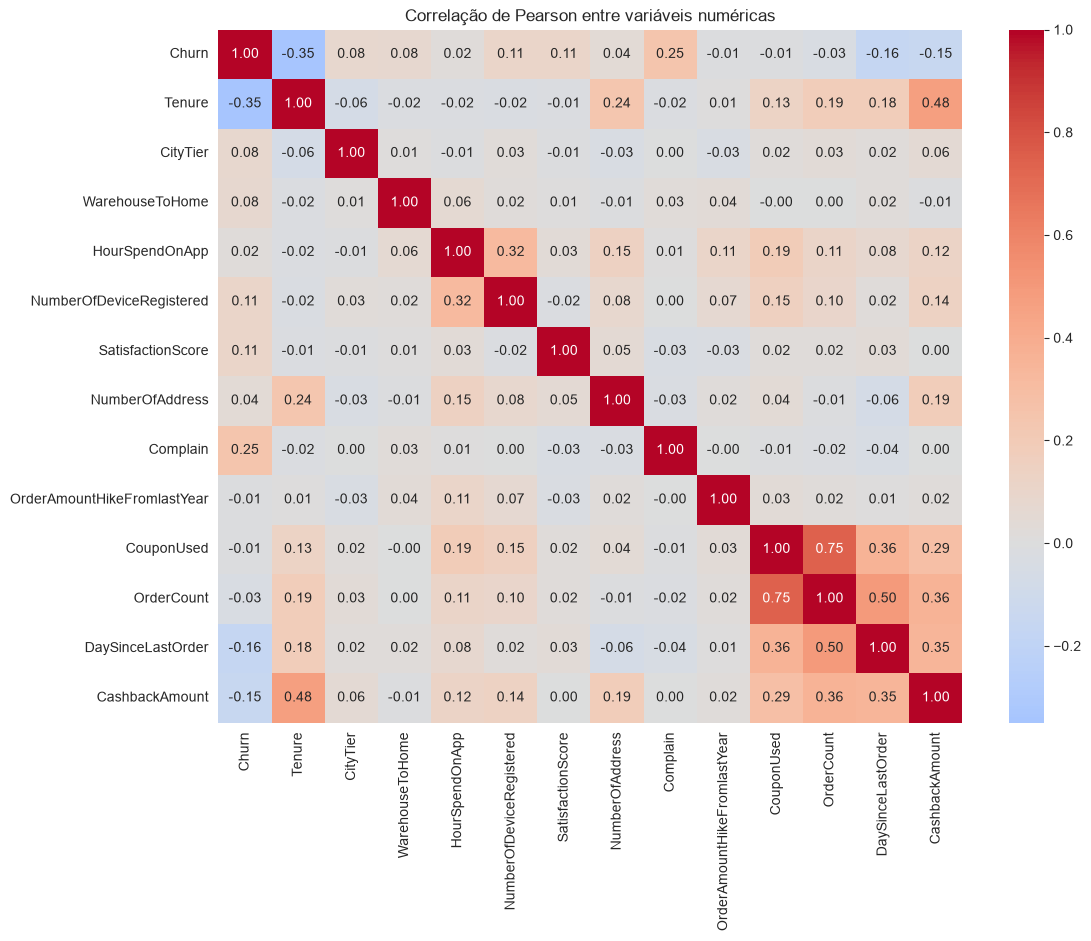

In [107]:
# Gráfico 9 - Mapa de calor: correlação de Pearson entre as variáveis numéricas
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include=np.number).drop(columns="CustomerID").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação de Pearson entre variáveis numéricas")
plt.show()

### Tomada de decisão (interpretação da EDA) ###

A base tem 5.630 linhas e 20 colunas, sem nenhuma linha duplicada. Sete colunas numéricas têm valores nulos (`Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, `DaySinceLastOrder`), todas com no máximo ~5,5% de ausência — volume pequeno, mas que ainda precisa ser tratado.

O gráfico de barras confirma o desbalanceamento citado no desafio: apenas 948 clientes (16,8%) deram churn contra 4.682 (83,2%) que ficaram.

O histograma do Tenure e o mapa de calor mostram que clientes mais novos (Tenure baixo) concentram a maior parte dos churns — correlação negativa de -0,35, a mais forte da base. `Complain` tem correlação positiva (+0,25): quem reclama cancela mais.

Até mesmo os mais obvios como `SatisfactionScore`não é afirmativo que será churn.


## Fase 2: Tratamento e Limpeza (Data Prep) ##

Nesta fase, vou limpar e preparar a base de dados para as próximas etapas. Primeiro, vou identificar e remover linhas duplicadas e verificar quais colunas possuem valores nulos. Depois, vou preencher esses valores usando a média ou a mediana, justificando a minha escolha de acordo com as características dos dados.

Também vou identificar os outliers, que são valores muito diferentes dos demais, usando gráficos ou análises simples. Em seguida, vou decidir se eles serão removidos, ajustados ou mantidos, explicando o motivo. Vou considerar que o KNN é mais sensível a esses valores, enquanto a Árvore de Decisão costuma lidar melhor com eles.

In [68]:
#Duplicadas: Identifique e remova linhas duplicadas que geram redundância.

# Duplicados e valores nulos
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


Há valores duplicados, 614 linhas (10.90%) quando analisamos os dados puro, sem o customerID. Eu entendo que não são duplicados mas dados corretos pois são situações de compra então devemos manter os dados e analisar eles como dados corretos.

Duplicados que deveriam ser tratatos é quando consideramos o mesmo customerID repetido no df.

In [109]:
# Valores Nulos: Identifique as colunas com dados ausentes. É obrigatório justifi car textualmente a escolha da técnica de imputação: usou a Média (indicada para distribuições normais/simétricas) ou a Mediana (indicada para mitigar o impacto de outliers)?

print("Colunas e seus respectivos nulos")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
percentual = (nulos / len(df) * 100).round(2)
pd.DataFrame({"qtd_nulos": nulos, "percentual (%)": percentual})

Colunas e seus respectivos nulos


,qtd_nulos,percentual (%)
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


In [110]:
print("Colunas com dados nulos e respectivos dados estatísticos")

colunas_com_nulo = nulos.index.tolist()

resumo_nulos = pd.DataFrame({
    "media": df[colunas_com_nulo].mean(),
    "mediana": df[colunas_com_nulo].median(),
    "skew": df[colunas_com_nulo].skew(),
}).round(2)
display(resumo_nulos)

Colunas com dados nulos e respectivos dados estatísticos


,media,mediana,skew
DaySinceLastOrder,4.54,3.0,1.19
OrderAmountHikeFromlastYear,15.71,15.0,0.79
Tenure,10.19,9.0,0.74
OrderCount,3.01,2.0,2.20
CouponUsed,1.75,1.0,2.55
HourSpendOnApp,2.93,3.0,-0.03
WarehouseToHome,15.64,14.0,1.62


### Justificativa da imputação ###

- Em geral tivemos nulos de 4.46 a 5.45%, valores controlados para uso da media ou mediana.

- Também vou analisar o *skew* para verificar a assimetria dos dados. Quando o *skew* é positivo, significa que existem valores mais altos concentrados à direita da distribuição; quando é negativo, há valores mais baixos concentrados à esquerda. Um *skew* próximo de zero indica uma distribuição mais equilibrada, enquanto um valor como 3 representa uma forte assimetria positiva, com alguns valores muito altos influenciando a distribuição.

- `Tenure` (skew 0,74) e `OrderAmountHikeFromlastYear` (skew 0,79): assimetria moderada, média e mediana já diferem (10,19 vs 9,0 / 15,71 vs 15,0) → uso a **mediana**.

- `WarehouseToHome` (skew 1,62) e `DaySinceLastOrder` (skew 1,19): assimetria alta, boxplot mostra outliers acima do pavil superior → uso a **mediana**, para não deixar a imputação puxada pelos poucos clientes com valores muito altos.

- `CouponUsed` (skew 2,55) e `OrderCount` (skew 2,20): as mais assimétricas da base, com outliers evidentes no boxplot → uso a **mediana**.

- `HourSpendOnApp` (skew -0,03): distribuição praticamente simétrica, média e mediana quase iguais (2,93 vs 3,0) → aqui a **média** já seria segura, mas por consistência com o restante do pipeline uso a **mediana** também (diferença de resultado é desprezível nesse caso).

- ***Conclusão***: como a base é dominada por variáveis assimétricas com outliers, vide boxplot abaixo, a estratégia adotada para todas as colunas com nulo é a **input pela mediana**.

Boxplot das colunas com nulos


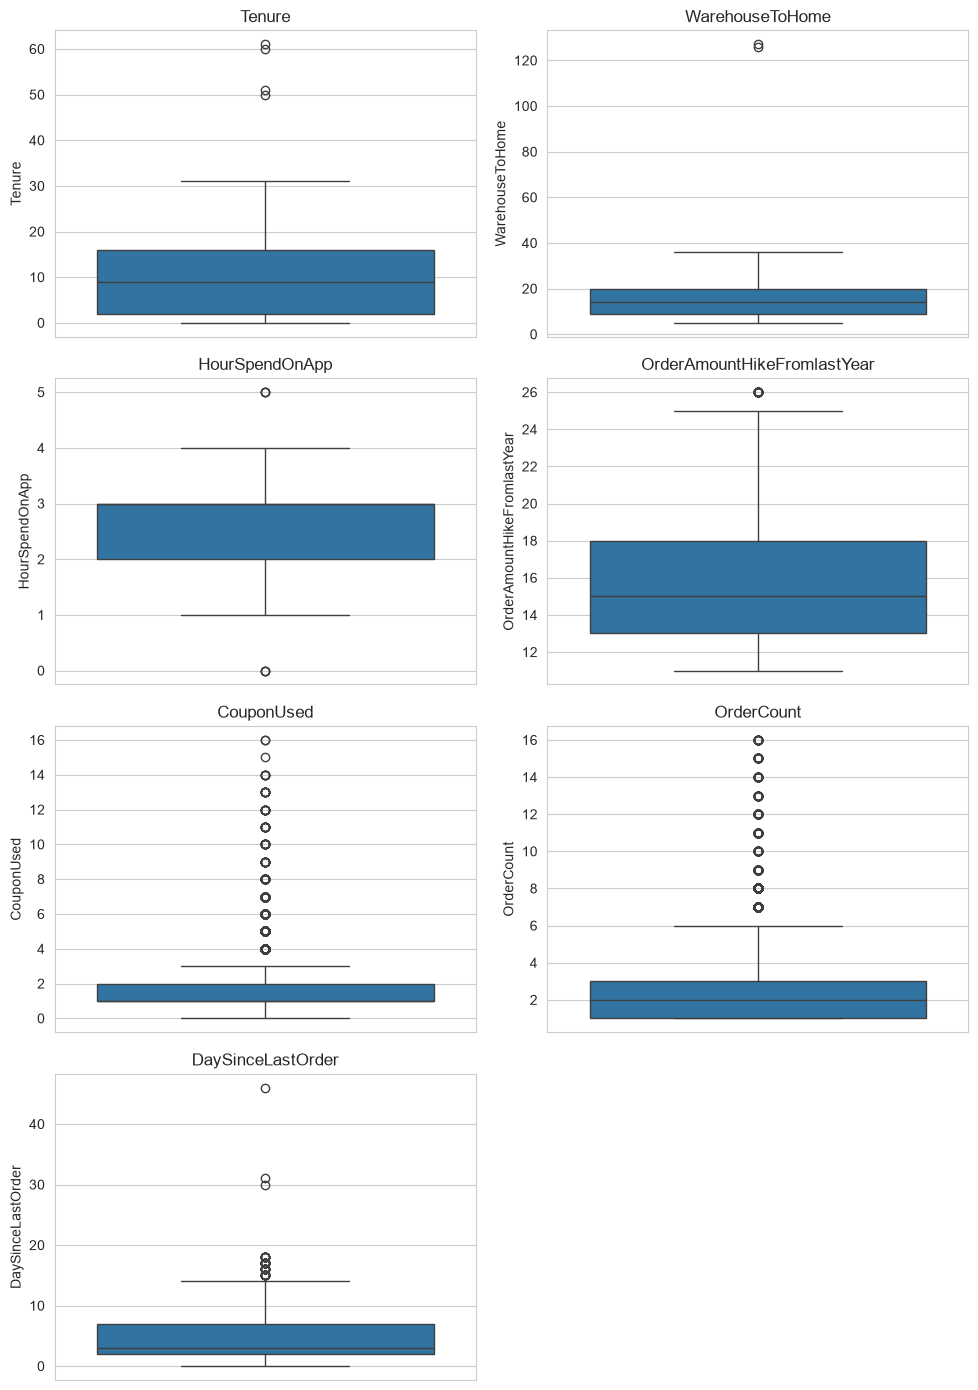

In [111]:
# Boxplots das colunas com nulo
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

print("Boxplot das colunas com nulos")   

sns.boxplot(y=df["Tenure"], ax=axes[0, 0])
axes[0, 0].set_title("Tenure")

sns.boxplot(y=df["WarehouseToHome"], ax=axes[0, 1])
axes[0, 1].set_title("WarehouseToHome")

sns.boxplot(y=df["HourSpendOnApp"], ax=axes[1, 0])
axes[1, 0].set_title("HourSpendOnApp")

sns.boxplot(y=df["OrderAmountHikeFromlastYear"], ax=axes[1, 1])
axes[1, 1].set_title("OrderAmountHikeFromlastYear")

sns.boxplot(y=df["CouponUsed"], ax=axes[2, 0])
axes[2, 0].set_title("CouponUsed")

sns.boxplot(y=df["OrderCount"], ax=axes[2, 1])
axes[2, 1].set_title("OrderCount")

sns.boxplot(y=df["DaySinceLastOrder"], ax=axes[3, 0])
axes[3, 0].set_title("DaySinceLastOrder")

axes[3, 1].axis("off")  # espaço sobrando na grade (7 gráficos em 8 posições)

plt.tight_layout()
plt.show()

# Tratamento de valores nulos #

In [112]:
# Imputação: mediana de cada coluna, calculada e aplicada só nela mesma
for coluna in colunas_com_nulo:
    mediana = df[coluna].median()
    df[coluna] = df[coluna].fillna(mediana)

print("Nulos restantes por coluna:")
df[colunas_com_nulo].isnull().sum()

Nulos restantes por coluna:


DaySinceLastOrder              0
OrderAmountHikeFromlastYear    0
Tenure                         0
OrderCount                     0
CouponUsed                     0
HourSpendOnApp                 0
WarehouseToHome                0
dtype: int64

### Tratamento Outliers ###

**O que é clipping e por que usar**

Clipping (ou capping/flooring) é uma técnica de tratamento de outliers que limita os valores extremos aos limites estatísticos do boxplot, em vez de excluir as observações inteiras.

Fórmula do método IQR
O boxplot usa o Intervalo Interquartil (IQR) para definir os "bigodes":
IQR = 𝑄3 − 𝑄1

Limite inferior=Q1−1,5×IQR
Limite superior=Q3+1,5×IQR

Onde:
Q1 = 25º percentil (primeiro quartil)
Q3 = 75º percentil (terceiro quartil)

Qualquer valor abaixo do limite inferior é substituído pelo próprio limite inferior. Qualquer valor acima do limite superior é substituído pelo limite superior

**Conclusão:** Desta forma não excluimos dados, principalmente os com churn = 1 que são importantes e já há desbalanceamento no dataset.

In [113]:
# Investiga outliers em TODAS as colunas numéricas (não categóricas), pela regra do boxplot (IQR)
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
colunas_numericas.remove("CustomerID")  # é só um identificador, não é uma variável de verdade
colunas_numericas.remove("Churn")       # é o alvo que queremos prever, não uma variável explicativa

linhas = []
for coluna in colunas_numericas:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    qtd_outliers = ((df[coluna] < limite_inferior) | (df[coluna] > limite_superior)).sum()
    pct_outliers = round(100 * qtd_outliers / len(df), 1)

    linhas.append([coluna, round(df[coluna].skew(), 2), qtd_outliers, pct_outliers])

print("Diagnostico dos outliers")
resumo_outliers = pd.DataFrame(linhas, columns=["coluna", "skew", "qtd_outliers", "pct_outliers"])
resumo_outliers = resumo_outliers.sort_values("pct_outliers", ascending=False)
resumo_outliers

Diagnostico dos outliers


,coluna,skew,qtd_outliers,pct_outliers
10,OrderCount,2.28,703,12.5
9,CouponUsed,2.63,629,11.2
12,CashbackAmount,1.15,447,7.9
4,NumberOfDeviceRegistered,-0.40,397,7.1
11,DaySinceLastOrder,1.27,62,1.1
8,OrderAmountHikeFromlastYear,0.84,33,0.6
6,NumberOfAddress,1.09,4,0.1
3,HourSpendOnApp,-0.04,6,0.1
0,Tenure,0.77,4,0.1
1,CityTier,0.74,0,0.0


## Tratamento das colunas com outliers ##

In [114]:
# Clipping: trata só as colunas que a investigação acima mostrou ter outlier (qtd_outliers > 0)
colunas_outliers = resumo_outliers[resumo_outliers["qtd_outliers"] > 0]["coluna"].tolist()
print("Colunas com outlier a tratar:", colunas_outliers)

for coluna in colunas_outliers:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df[coluna] = df[coluna].clip(lower=limite_inferior, upper=limite_superior)

print("Outliers tratados: valores extremos foram limitados aos limites do boxplot.")

Colunas com outlier a tratar: ['OrderCount', 'CouponUsed', 'CashbackAmount', 'NumberOfDeviceRegistered', 'DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 'NumberOfAddress', 'HourSpendOnApp', 'Tenure', 'WarehouseToHome']
Outliers tratados: valores extremos foram limitados aos limites do boxplot.


In [115]:
# Verificação dos outliers apos tratamento
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
colunas_numericas.remove("CustomerID")  # é só um identificador, não é uma variável de verdade
colunas_numericas.remove("Churn")       # é o alvo que queremos prever, não uma variável explicativa

linhas = []
for coluna in colunas_numericas:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    qtd_outliers = ((df[coluna] < limite_inferior) | (df[coluna] > limite_superior)).sum()
    pct_outliers = round(100 * qtd_outliers / len(df), 1)

    linhas.append([coluna, round(df[coluna].skew(), 2), qtd_outliers, pct_outliers])

print("Outliers tratados: valores extremos foram limitados aos limites do boxplot.")

resumo_outliers = pd.DataFrame(linhas, columns=["coluna", "skew", "qtd_outliers", "pct_outliers"])
resumo_outliers = resumo_outliers.sort_values("pct_outliers", ascending=False)
resumo_outliers

Outliers tratados: valores extremos foram limitados aos limites do boxplot.


,coluna,skew,qtd_outliers,pct_outliers
0,Tenure,0.69,0,0.0
1,CityTier,0.74,0,0.0
2,WarehouseToHome,0.94,0,0.0
3,HourSpendOnApp,-0.03,0,0.0
4,NumberOfDeviceRegistered,-0.30,0,0.0
5,SatisfactionScore,-0.14,0,0.0
6,NumberOfAddress,0.97,0,0.0
7,Complain,0.95,0,0.0
8,OrderAmountHikeFromlastYear,0.82,0,0.0
9,CouponUsed,0.53,0,0.0


**Impacto nos modelos**

- **KNN** calcula distância entre pontos. Um outlier bem longe distorce essa distância e pode enganar o modelo — por isso o clipping ajuda o KNN.
- **Árvore de Decisão** só faz perguntas do tipo "valor > X?", então um outlier isolado não muda a árvore quase nada — ela é robusta a isso, com ou sem o tratamento.

## Fase 3 - Feature Engineering ##

(E-commerce): crie a coluna cashback_por_pedido = CashbackAmount / OrderCount.

In [116]:
# Criando nova coluna com a media de cashback por usuario

df["cashback_por_pedido"] = df["CashbackAmount"] / df["OrderCount"]

# Confere se sobrou algum problema (NaN ou infinito) mesmo assim
print("Nulos em cashback_por_pedido:", df["cashback_por_pedido"].isnull().sum())
print("Infinitos em cashback_por_pedido:", np.isinf(df["cashback_por_pedido"]).sum())

df[["CashbackAmount", "OrderCount", "cashback_por_pedido"]].head()

Nulos em cashback_por_pedido: 0
Infinitos em cashback_por_pedido: 0


,CashbackAmount,OrderCount,cashback_por_pedido
0,160,1.0,160.0
1,121,1.0,121.0
2,120,1.0,120.0
3,134,1.0,134.0
4,130,1.0,130.0


In [117]:
# Sumário estatístico descritivo da nova coluna (médias, mínimos, máximos, quartis)

print("Sumário estatístico descritivo - Cashback por pedido")

df["cashback_por_pedido"].describe()


Sumário estatístico descritivo - Cashback por pedido


count    5630.000000
mean       96.257738
std        50.480359
min        11.833333
25%        56.000000
50%        87.000000
75%       129.000000
max       271.000000
Name: cashback_por_pedido, dtype: float64

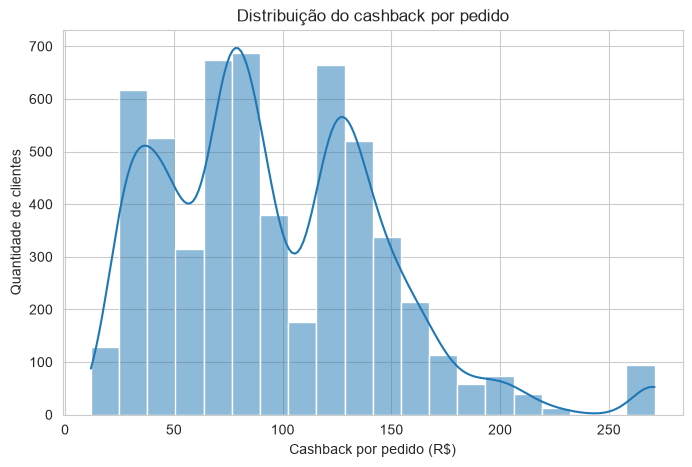

In [118]:
# Histograma: distribuição do cashback por pedido
plt.figure(figsize=(8, 5))
sns.histplot(df["cashback_por_pedido"], bins=20, kde=True)
plt.title("Distribuição do cashback por pedido")
plt.xlabel("Cashback por pedido (R$)")
plt.ylabel("Quantidade de clientes")
plt.show()

## Fase 4: Separação, Balanceamento e Escalonamento Seguro ##

### Encoding ###

Converta colunas textuais/categóricas em formato numérico utilizando técnicas adequadas (como One-Hot Encoding ou Label Encoding).

Analisando as colunas não faz sentido usar o label encoding, pois as colunas não tem diferença entre os valores que deva ser utilizada pelos modelos.
Exemplo: Metodo de pagamento o cartão de crédito não é melhor que cartão de débito ou COD,

In [119]:
# One-Hot Encoding: transforma cada categoria em uma coluna 0/1
colunas_categoricas = df.select_dtypes(include="str").columns.tolist()
print("Colunas categóricas a converter:", colunas_categoricas)
print("Colunas antes do encoding:", df.shape[1])

df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

print("Colunas depois do encoding:", df.shape[1])
df.head()

Colunas categóricas a converter: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
Colunas antes do encoding: 21
Colunas depois do encoding: 32


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4.0,3,6.0,3.0,3.0,2,9,1,...,False,False,False,False,True,False,False,False,False,True
1,50002,1,9.0,1,8.0,3.0,4.0,3,7,1,...,False,True,True,False,False,True,False,False,False,True
2,50003,1,9.0,1,30.0,2.0,4.0,3,6,1,...,False,False,True,False,False,True,False,False,False,True
3,50004,1,0.0,3,15.0,2.0,4.0,5,8,0,...,False,False,True,False,True,False,False,False,False,True
4,50005,1,0.0,1,12.0,3.0,3.0,5,3,0,...,False,False,True,False,False,True,False,False,False,True


### Split de Dados ###

Separe as variáveis preditoras (X) do alvo (y) e divida em Treino e Teste (test_size=0.20), aplicando o parâmetro stratify=y para preservar a proporção das classes.

Vou separar os dados em treino (80%) e teste (20%) e aplicar o balanceamento somente nos dados de treino. Dessa forma, evitarei o vazamento de dados e manterei os dados de teste representando uma situação mais próxima da realidade.

In [121]:
print(f"Dataset atualizado ->Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")


# X = tudo que ajuda a prever, y = o que queremos prever (Churn)
X = df.drop(columns=["Churn", "CustomerID"])
y = df["Churn"]

# stratify=y garante que treino e teste fiquem com a mesma proporção de Churn 0/1 que a base original
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Treino_Shape:", X_train.shape, "| Teste_Shape:", X_test.shape)
print("\nProporção de Churn no treino:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporção de Churn no teste:")
print(y_test.value_counts(normalize=True).round(3))

Dataset atualizado ->Linhas: 5630 | Colunas: 32
Treino_Shape: (4504, 30) | Teste_Shape: (1126, 30)

Proporção de Churn no treino:
Churn
0    0.832
1    0.168
Name: proportion, dtype: float64

Proporção de Churn no teste:
Churn
0    0.831
1    0.169
Name: proportion, dtype: float64


### Balanceamento de classes ###

Como as duas bases possuem classes desbalanceadas, vou aplicar uma técnica de reamostragem, como SMOTE ou *Random Under Sampling*, para equilibrar a quantidade de exemplos entre as classes. 

Regra de ouro: balancear só o TREINO. O teste continua desbalanceado de propósito,
porque ele representa a realidade (clientes de verdade), e é assim que o modelo
 vai ser avaliado depois. Balancear o teste também seria vazamento de dados (data leakage).


Escolhi utilizar o **SMOTE** em vez do *Random Under Sampling* porque a base de dados é relativamente pequena e a classe minoritária possui poucos exemplos. O *Random Under Sampling* descartaria 66% dos registros da classe majoritária, prejudicando os dados do treino e reduzindo a quantidade de informações disponíveis para o modelo.

Já o SMOTE mantém todos os dados reais e cria exemplos sintéticos da classe minoritária, aumentando o conjunto de treino. Apesar de poder gerar alguns exemplos artificiais, essa desvantagem é menor do que perder uma grande quantidade de dados reais. Por isso, neste caso, o SMOTE oferece um melhor equilíbrio entre preservar informações e corrigir o desbalanceamento das classes.




In [123]:
print("Treino antes do SMOTE:")
print(y_train.value_counts())


smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nTreino depois do SMOTE:")
print(y_train_bal.value_counts())

Treino antes do SMOTE:
Churn
0    3746
1     758
Name: count, dtype: int64

Treino depois do SMOTE:
Churn
0    3746
1    3746
Name: count, dtype: int64


### Escalonamento Seguro ###
Vou aplicar o `StandardScaler` somente nas variáveis contínuas usadas pelo modelo KNN. Primeiro, vou utilizar o `fit_transform` nos dados de treino já balanceados e, depois, apenas o `transform` nos dados de teste, evitando o vazamento de dados. Para a Árvore de Decisão, vou usar os dados sem escalonamento, pois esse modelo realiza cortes independentes da escala das variáveis.

 **O que cada função faz**

- **`StandardScaler`**: padroniza os valores das variáveis, deixando-os em uma escala comparável. Isso é importante no KNN porque ele calcula distâncias entre os dados.

- **`fit`**: aprende os valores necessários para a padronização, principalmente a média e o desvio padrão dos dados de treino.

- **`transform`**: aplica essa padronização usando a média e o desvio padrão já aprendidos.

- **`fit_transform`**: executa o `fit` e o `transform` juntos. Deve ser usado nos dados de treino, neste caso, após o balanceamento.


- **Árvore de Decisão sem escalonamento**: a árvore escolhe pontos de corte nas variáveis, como “idade menor que 30” ou “renda maior que 5.000”. Por isso, ela não depende da distância entre os valores nem precisa que as variáveis estejam na mesma escala.

- Em resumo: uso `fit_transform` no treino, `transform` no teste e não aplico o `StandardScaler` na Árvore de Decisão.

In [125]:
# Variáveis contínuas a escalonar 
colunas_continuas = [
    "Tenure", "CityTier", "WarehouseToHome", "HourSpendOnApp",
    "NumberOfDeviceRegistered", "SatisfactionScore", "NumberOfAddress", "Complain",
    "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount", "DaySinceLastOrder",
    "CashbackAmount", "cashback_por_pedido",
]

scaler = StandardScaler()

# Cópias só pro KNN, pra não misturar com os dados 
X_train_knn = X_train_bal.copy()
X_test_knn = X_test.copy()

# Escalonamento seguro: fit_transform aprende média/desvio SÓ no treino balanceado;
X_train_knn[colunas_continuas] = scaler.fit_transform(X_train_bal[colunas_continuas])
X_test_knn[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

print("Antes do escalonamento (treino):")
display(X_train_bal[colunas_continuas].head(3))

print("Depois do escalonamento (treino):")
display(X_train_knn[colunas_continuas].head(3))

Antes do escalonamento (treino):


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,cashback_por_pedido
0,9.0,3,16.0,2.0,3.0,1,2,0,14.0,3.5,6.0,7.0,200,33.333333
1,6.0,3,13.0,1.0,3.0,4,1,0,17.0,0.0,1.0,2.0,143,143.000000
2,8.0,1,15.0,3.0,4.0,4,10,0,19.0,0.0,1.0,0.0,165,165.000000


Depois do escalonamento (treino):


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,cashback_por_pedido
0,0.194512,1.489874,0.006863,-1.405449,-0.883378,-1.594797,-0.866922,-0.639789,-0.434410,1.989304,2.112225,0.972578,0.762725,-1.275719
1,-0.186828,1.489874,-0.372107,-2.905477,-0.883378,0.712700,-1.276080,-0.639789,0.423721,-1.380990,-0.872477,-0.580370,-0.626101,1.041108
2,0.067398,-0.761692,-0.119460,0.094579,0.229359,0.712700,2.406344,-0.639789,0.995809,-1.380990,-0.872477,-1.201549,-0.090063,1.505882


**Resumo Fase 4**

Depois do escalonamento, o pipeline de dados está pronto — a partir daqui é só modelagem.

**Dados disponíveis para a Árvore de Decisão:** `X_train_bal` e `y_train_bal` (treino balanceado pelo SMOTE, sem escalonar) contra `X_test`/`y_test` (teste original, desbalanceado, sem escalonar).

**Dados disponíveis para o KNN:** `X_train_knn` e `y_train_bal` (mesmo treino balanceado, com as 14 variáveis contínuas escalonadas) contra `X_test_knn`/`y_test`.

## Fase 5: Modelagem e Validação (O Desafio do Overfitting) ## 

Vou testar diferentes valores de `n_neighbors` no KNN e de `max_depth` na Árvore de Decisão. Depois, vou comparar as métricas de desempenho nos dados de treino e de teste, usando tabelas ou gráficos para verificar se houve *overfitting*. Por fim, vou escolher a configuração que apresentar o melhor equilíbrio entre o desempenho no treino e a capacidade de generalização nos dados de teste, evitando que o modelo apenas memorize os dados de treino.

### Otimização do KNN ###

Varie o parâmetro n_neighbors (K) testando no mínimo 4 valores distintos (ex: K = 3, 5, 7 e 9)


In [130]:
# Testando vários valores de K (3 a 16): recall, F1 e acurácia no treino e no teste
# Recall e F1 são as métricas principais (critério de negócio + equilíbrio precisão/recall)
# Acurácia aparece por completude — gap treino/teste é estrutural (SMOTE vs realidade), não overfitting
valores_k = range(3, 16)
recall_treino_knn = []
recall_teste_knn  = []
f1_treino_knn     = []
f1_teste_knn      = []
acc_treino_knn    = []
acc_teste_knn     = []

for k in valores_k:
    modelo_knn = KNeighborsClassifier(n_neighbors=k)
    modelo_knn.fit(X_train_knn, y_train_bal)

    pred_treino = modelo_knn.predict(X_train_knn)
    pred_teste  = modelo_knn.predict(X_test_knn)

    recall_treino_knn.append(recall_score(y_train_bal, pred_treino))
    recall_teste_knn.append(recall_score(y_test, pred_teste))
    f1_treino_knn.append(f1_score(y_train_bal, pred_treino))
    f1_teste_knn.append(f1_score(y_test, pred_teste))
    acc_treino_knn.append(accuracy_score(y_train_bal, pred_treino))
    acc_teste_knn.append(accuracy_score(y_test, pred_teste))

resultados_knn = pd.DataFrame({
    "k":                  list(valores_k),
    "recall_treino (%)":  [v * 100 for v in recall_treino_knn],
    "recall_teste (%)":   [v * 100 for v in recall_teste_knn],
    "f1_treino (%)":      [v * 100 for v in f1_treino_knn],
    "f1_teste (%)":       [v * 100 for v in f1_teste_knn],
    "acc_treino (%)":     [v * 100 for v in acc_treino_knn],
    "acc_teste (%)":      [v * 100 for v in acc_teste_knn],
}).round(1)
display(resultados_knn)

,k,recall_treino (%),recall_teste (%),f1_treino (%),f1_teste (%),acc_treino (%),acc_teste (%)
0,3,99.8,94.2,98.5,74.0,98.5,88.8
1,4,99.4,90.5,98.7,75.6,98.7,90.1
2,5,99.6,94.2,95.8,69.0,95.6,85.7
3,6,99.1,90.5,96.4,70.5,96.3,87.2
4,7,99.5,93.7,93.9,65.4,93.6,83.3
5,8,98.9,90.0,94.6,67.9,94.4,85.6
6,9,99.3,93.2,92.7,64.8,92.2,82.9
7,10,98.7,90.5,93.6,65.6,93.3,84.0
8,11,99.1,92.1,91.9,63.4,91.2,82.1
9,12,98.6,88.9,92.5,64.0,92.0,83.1


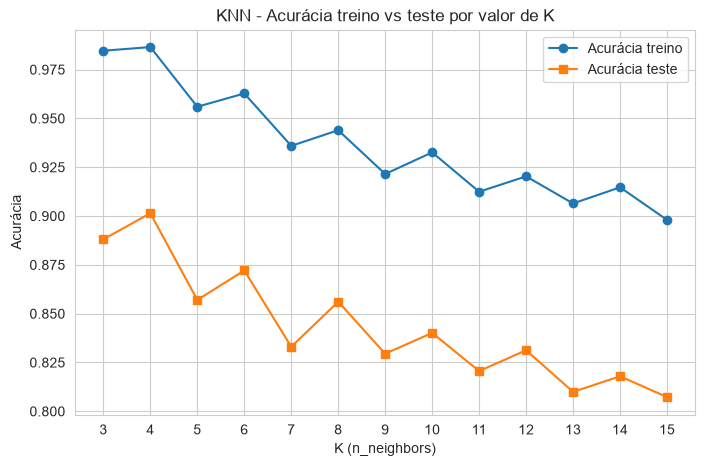

In [131]:
# Gráfico de acurácia treino vs teste por K
# O gap entre as linhas é estrutural: treino SMOTE (50/50) vs teste real (16,8% churn)
# — por isso o recall (célula anterior) é o critério correto; a acurácia complementa a leitura
plt.figure(figsize=(8, 5))
plt.plot(valores_k, acc_treino_knn, marker="o", label="Acurácia treino")
plt.plot(valores_k, acc_teste_knn,  marker="s", label="Acurácia teste")
plt.title("KNN - Acurácia treino vs teste por valor de K")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Acurácia")
plt.xticks(valores_k)
plt.grid(True)
plt.legend()
plt.show()

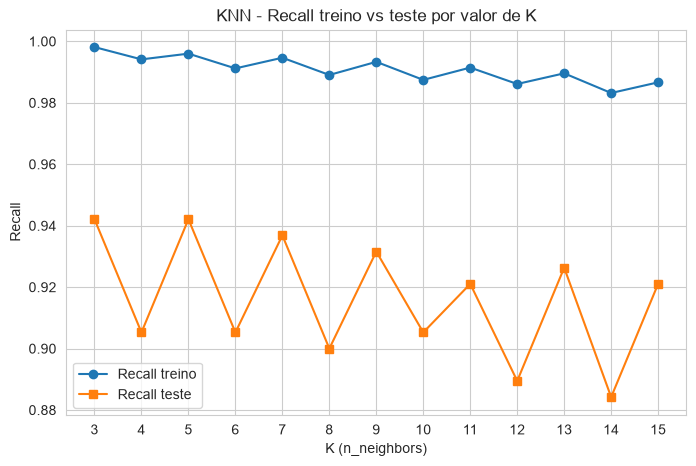

In [132]:
# Gráfico: linha do treino acima da linha do teste = sinal de overfitting
plt.figure(figsize=(8, 5))
plt.plot(valores_k, recall_treino_knn, marker="o", label="Recall treino")
plt.plot(valores_k, recall_teste_knn,  marker="s", label="Recall teste")
plt.title("KNN - Recall treino vs teste por valor de K")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Recall")
plt.xticks(valores_k)
plt.grid(True)
plt.legend()
plt.show()

In [133]:
# Tabela com várias métricas do KNN para cada K de 3 a 16, avaliadas no teste
valores_k_metricas = range(3, 16)
linhas_metricas = []

for k in valores_k_metricas:
    modelo_knn_k = KNeighborsClassifier(n_neighbors=k)
    modelo_knn_k.fit(X_train_knn, y_train_bal)
    pred_k = modelo_knn_k.predict(X_test_knn)

    # Matriz de confusão: verdadeiro/falso positivo/negativo, um por K
    tn, fp, fn, tp = confusion_matrix(y_test, pred_k).ravel()

    linhas_metricas.append({
        "k": k,
        "acuracia": accuracy_score(y_test, pred_k),
        "precisao": precision_score(y_test, pred_k),
        "recall": recall_score(y_test, pred_k),
        "f1_score": f1_score(y_test, pred_k),
        "verdadeiro_negativo": tn,
        "falso_positivo": fp,
        "falso_negativo": fn,
        "verdadeiro_positivo": tp,
    })

resultados_knn_metricas = pd.DataFrame(linhas_metricas).round(3)
display(resultados_knn_metricas)

,k,acuracia,precisao,recall,f1_score,verdadeiro_negativo,falso_positivo,falso_negativo,verdadeiro_positivo
0,3,0.888,0.609,0.942,0.740,821,115,11,179
1,4,0.901,0.649,0.905,0.756,843,93,18,172
2,5,0.857,0.544,0.942,0.690,786,150,11,179
3,6,0.872,0.577,0.905,0.705,810,126,18,172
4,7,0.833,0.503,0.937,0.654,760,176,12,178
5,8,0.856,0.545,0.900,0.679,793,143,19,171
6,9,0.829,0.497,0.932,0.648,757,179,13,177
7,10,0.840,0.515,0.905,0.656,774,162,18,172
8,11,0.821,0.483,0.921,0.634,749,187,15,175
9,12,0.831,0.500,0.889,0.640,767,169,21,169


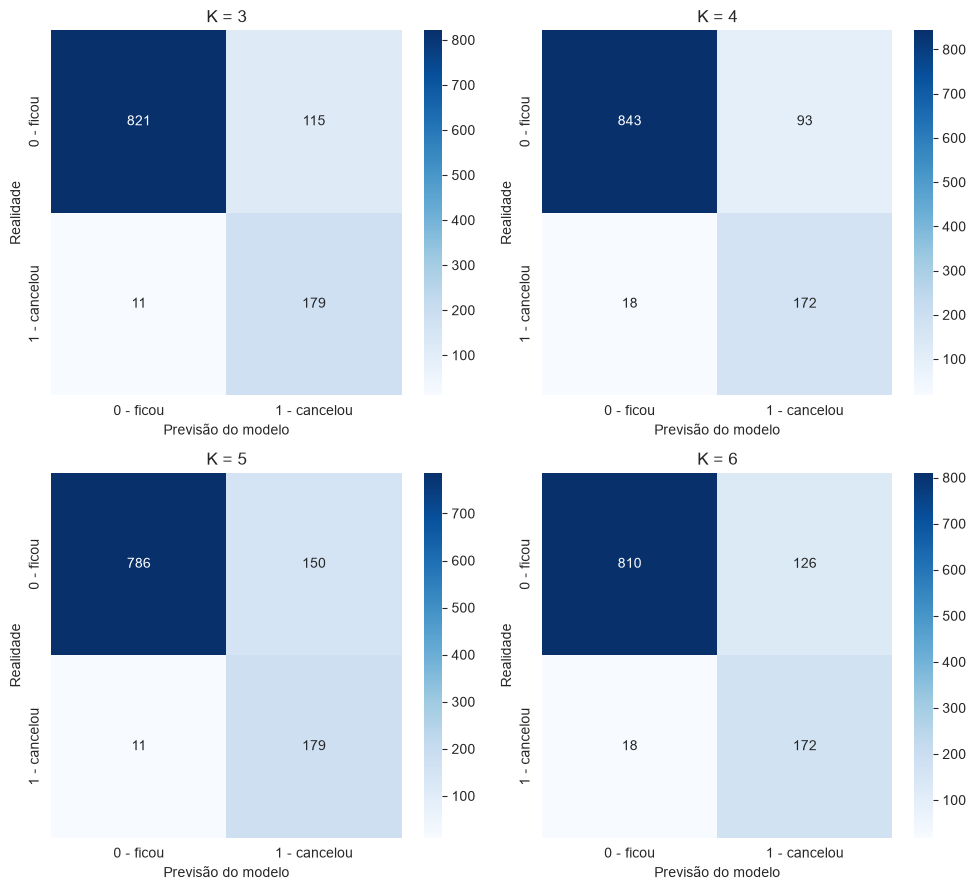

In [134]:
# Matrizes de confusão detalhadas para K = 3, 4, 5 e 6
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

modelo_knn_3 = KNeighborsClassifier(n_neighbors=3)
modelo_knn_3.fit(X_train_knn, y_train_bal)
pred_3 = modelo_knn_3.predict(X_test_knn)
sns.heatmap(confusion_matrix(y_test, pred_3), annot=True, fmt="d", cmap="Blues",
            xticklabels=["0 - ficou", "1 - cancelou"], yticklabels=["0 - ficou", "1 - cancelou"], ax=axes[0, 0])
axes[0, 0].set_title("K = 3")
axes[0, 0].set_xlabel("Previsão do modelo")
axes[0, 0].set_ylabel("Realidade")

modelo_knn_4 = KNeighborsClassifier(n_neighbors=4)
modelo_knn_4.fit(X_train_knn, y_train_bal)
pred_4 = modelo_knn_4.predict(X_test_knn)
sns.heatmap(confusion_matrix(y_test, pred_4), annot=True, fmt="d", cmap="Blues",
            xticklabels=["0 - ficou", "1 - cancelou"], yticklabels=["0 - ficou", "1 - cancelou"], ax=axes[0, 1])
axes[0, 1].set_title("K = 4")
axes[0, 1].set_xlabel("Previsão do modelo")
axes[0, 1].set_ylabel("Realidade")

modelo_knn_5 = KNeighborsClassifier(n_neighbors=5)
modelo_knn_5.fit(X_train_knn, y_train_bal)
pred_5 = modelo_knn_5.predict(X_test_knn)
sns.heatmap(confusion_matrix(y_test, pred_5), annot=True, fmt="d", cmap="Blues",
            xticklabels=["0 - ficou", "1 - cancelou"], yticklabels=["0 - ficou", "1 - cancelou"], ax=axes[1, 0])
axes[1, 0].set_title("K = 5")
axes[1, 0].set_xlabel("Previsão do modelo")
axes[1, 0].set_ylabel("Realidade")

modelo_knn_6 = KNeighborsClassifier(n_neighbors=6)
modelo_knn_6.fit(X_train_knn, y_train_bal)
pred_6 = modelo_knn_6.predict(X_test_knn)
sns.heatmap(confusion_matrix(y_test, pred_6), annot=True, fmt="d", cmap="Blues",
            xticklabels=["0 - ficou", "1 - cancelou"], yticklabels=["0 - ficou", "1 - cancelou"], ax=axes[1, 1])
axes[1, 1].set_title("K = 6")
axes[1, 1].set_xlabel("Previsão do modelo")
axes[1, 1].set_ylabel("Realidade")

plt.tight_layout()
plt.show()

In [135]:
# Validação cruzada do KNN com Pipeline (SMOTE → StandardScaler → KNN) dentro de cada dobra
# Cada dobra recebe seu próprio SMOTE — sem vazamento do validation set para o treino
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv_knn = []

for k in [3, 4, 5, 6]:
    pipeline_knn = Pipeline([
        ("smote",  SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=k)),
    ])

    scores_recall = cross_val_score(pipeline_knn, X_train, y_train, cv=cv, scoring="recall",  n_jobs=-1)
    scores_f1     = cross_val_score(pipeline_knn, X_train, y_train, cv=cv, scoring="f1",      n_jobs=-1)

    resultados_cv_knn.append({
        "k":                k,
        "recall_medio (%)": scores_recall.mean() * 100,
        "desvio_recall (%)":scores_recall.std()  * 100,
        "f1_medio (%)":     scores_f1.mean()     * 100,
        "desvio_f1 (%)":    scores_f1.std()      * 100,
    })

resultados_cv_knn = pd.DataFrame(resultados_cv_knn).round(2)
display(resultados_cv_knn)

,k,recall_medio (%),desvio_recall (%),f1_medio (%),desvio_f1 (%)
0,3,74.80,2.64,67.81,1.85
1,4,66.09,3.72,65.92,2.64
2,5,74.14,3.19,64.19,2.69
3,6,68.46,3.21,63.95,2.75


## Resumo modelo KNN ##

Escolhemos **K = 3** porque, neste problema, é mais prejudicial deixar de identificar um cliente que realmente pretende cancelar do que oferecer um cashback a um cliente que continuaria comprando. O primeiro caso é um **falso negativo** e pode representar a perda definitiva do cliente; o segundo é um **falso positivo** e representa apenas o custo de uma ação de retenção que talvez não fosse necessária.

Com K = 3, o modelo identificou corretamente **179 dos 190 clientes que cancelaram**, alcançando um *recall* de aproximadamente **94,2%**. Embora sua precisão seja de aproximadamente **60,9%**, fazendo com que alguns cashbacks sejam oferecidos a clientes que não cancelariam, essa troca é aceitável porque o custo do cashback tende a ser menor que o prejuízo de perder um cliente.

Apesar de o **K = 5** apresentar o mesmo *recall* de aproximadamente 94,2%, ele comete mais erros ao classificar clientes que permaneceriam: foram **150 falsos positivos**, contra **115 no K = 3**. Isso significa que o K = 5 poderia gerar mais ofertas desnecessárias e aumentar os custos com a retenção. Por esse motivo, escolhemos o **K = 3**, pois ele identifica a mesma quantidade proporcional de clientes em risco, mas com menos cashbacks desperdiçados.

O **K = 4** apresentou uma acurácia geral maior, de aproximadamente **90,1%**, contra **88,8%** no **K = 3**. Porém, a acurácia sozinha não é suficiente para escolher o melhor modelo. Mesmo com esse resultado, o **K = 4** deixou de identificar mais clientes que realmente cancelaram, cometendo 18 falsos negativos, contra **apenas 11** no **K = 3**. Portanto, escolhemos o **K = 3**, pois ele identifica mais clientes em risco e gera menos falsos negativos, mantendo o mesmo recall do **K = 5** e evitando mais cashbacks desnecessários.

A escolha foi confirmada pela **validação cruzada com 5 divisões / grupos**, usando `StratifiedKFold` que aplica o SMOTE dentro de cada grupo — garantindo que o conjunto de validação de cada rodada nunca viu dados sintéticos gerados com base nele mesmo. O K = 3 apresentou o maior recall médio e F1 entre os finalistas, confirmando que o bom resultado no conjunto de teste não foi acidente-sorte de uma única divisão.

### Otimização da Árvore ###

Varie o parâmetro max_depth (profundidade máxima) testando no mínimo 4 cenários (ex: profundidades 3, 5, 7 e ilimitada/None)

,max_depth,recall_treino,recall_teste,gap (treino-teste)
0,3,0.727176,0.668421,0.0588
1,5,0.809931,0.673684,0.1362
2,7,0.867325,0.715789,0.1515
3,8,0.888147,0.694737,0.1934
4,9,0.936733,0.768421,0.1683
5,10,0.937800,0.721053,0.2167
6,11,0.966631,0.784211,0.1824
7,12,0.975174,0.831579,0.1436
8,13,0.991458,0.863158,0.1283
9,14,0.989322,0.831579,0.1577


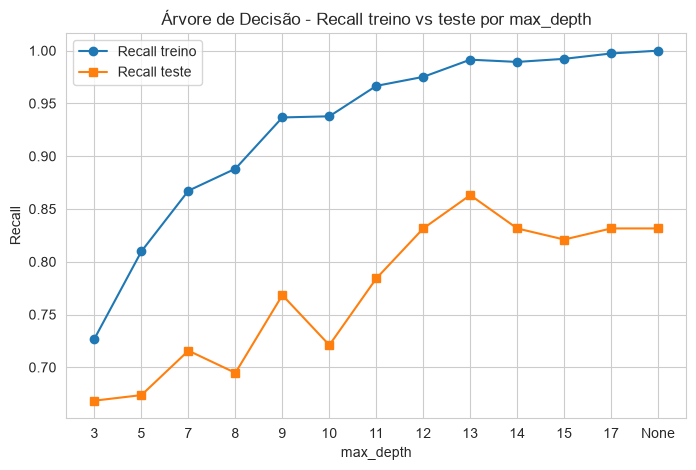

In [136]:
# Testando valores de max_depth, comparando recall no treino e no teste
# Recall é o critério de negócio: minimizar churns não detectados (falsos negativos)
valores_profundidade = [3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, None]
recall_treino_arvore = []
recall_teste_arvore  = []

for profundidade in valores_profundidade:
    modelo_arvore = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    modelo_arvore.fit(X_train_bal, y_train_bal)

    pred_treino = modelo_arvore.predict(X_train_bal)
    pred_teste  = modelo_arvore.predict(X_test)

    recall_treino_arvore.append(recall_score(y_train_bal, pred_treino))
    recall_teste_arvore.append(recall_score(y_test, pred_teste))

rotulos_profundidade = [str(p) if p is not None else "None" for p in valores_profundidade]

resultados_arvore = pd.DataFrame({
    "max_depth":        rotulos_profundidade,
    "recall_treino":    recall_treino_arvore,
    "recall_teste":     recall_teste_arvore,
    "gap (treino-teste)": [round(tr - te, 4) for tr, te in zip(recall_treino_arvore, recall_teste_arvore)],
})
display(resultados_arvore)

# Gráfico: onde a linha do treino começa a se afastar do teste = onde o overfitting começa
plt.figure(figsize=(8, 5))
plt.plot(rotulos_profundidade, recall_treino_arvore, marker="o", label="Recall treino")
plt.plot(rotulos_profundidade, recall_teste_arvore,  marker="s", label="Recall teste")
plt.title("Árvore de Decisão - Recall treino vs teste por max_depth")
plt.xlabel("max_depth")
plt.ylabel("Recall")
plt.grid(True)
plt.legend()
plt.show()

In [137]:
# Validação cruzada (5-fold) da Árvore com Pipeline (SMOTE → DecisionTree) dentro de cada dobra
# O SMOTE é aplicado apenas nos dados de treino de cada dobra — sem vazamento para o validation
# scoring=recall: alinhado com o critério de negócio (minimizar churns não detectados)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv_arvore = []

for profundidade in [8, 9, 10, 11, 12, 13, 14, 15, 17, None]:
    pipeline_arvore = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("dt",    DecisionTreeClassifier(max_depth=profundidade, random_state=42)),
    ])

    scores = cross_val_score(pipeline_arvore, X_train, y_train, cv=cv, scoring="recall", n_jobs=-1)

    resultados_cv_arvore.append({
        "max_depth":        profundidade if profundidade is not None else "None",
        "recall_medio (%)": scores.mean() * 100,
        "desvio_padrao (%)":scores.std()  * 100,
    })

resultados_cv_arvore = pd.DataFrame(resultados_cv_arvore).round(2)
display(resultados_cv_arvore)

,max_depth,recall_medio (%),desvio_padrao (%)
0,8,67.94,3.07
1,9,68.60,1.20
2,10,70.32,2.09
3,11,69.40,2.11
4,12,71.64,1.06
5,13,71.64,1.66
6,14,71.38,2.35
7,15,72.30,1.41
8,17,73.75,1.38
9,None,73.75,2.42


A tabela acima mostra o recall no treino, no teste e o gap - diferença entre eles para cada profundidade. O gap é o indicador de overfitting: enquanto ele permanece baixo, o modelo generaliza bem; quando cresce, o modelo está memorizando o treino. O gráfico torna essa inflexão visível.

Para confirmar qual profundidade fica antes de o overfitting se instalar, rodei uma **validação cruzada de 5 dobras** usando `Pipeline(SMOTE → Árvore)`, que aplica o SMOTE dentro de cada dobra — o conjunto de validação de cada rodada nunca recebe dados sintéticos. A métrica é **recall**, alinhada com o critério de negócio.

**Resumo:** O gráfico e a coluna `gap` na tabela acima mostram onde o overfitting começa: o gap entre treino e teste é baixo até profundidades menores e cresce progressivamente a partir de certo ponto, chegando ao máximo em `None` — que é justamente o caso que memoriza o treino.

A validação cruzada com recall confirma que profundidades maiores têm recall médio mais alto, mas o ganho fica dentro do ruído e vem ao custo de um gap crescente. **`max_depth=12`** é o ponto antes de o gap explodir: ainda tem recall competitivo na validação cruzada e mantém a diferença treino/teste sob controle.

**Portanto, mantemos `max_depth=12` como recomendação final**, com o argumento principal sendo o ponto de inflexão do gap — que é exatamente o que o diagnóstico de overfitting pede — e a validação cruzada como confirmação secundária.

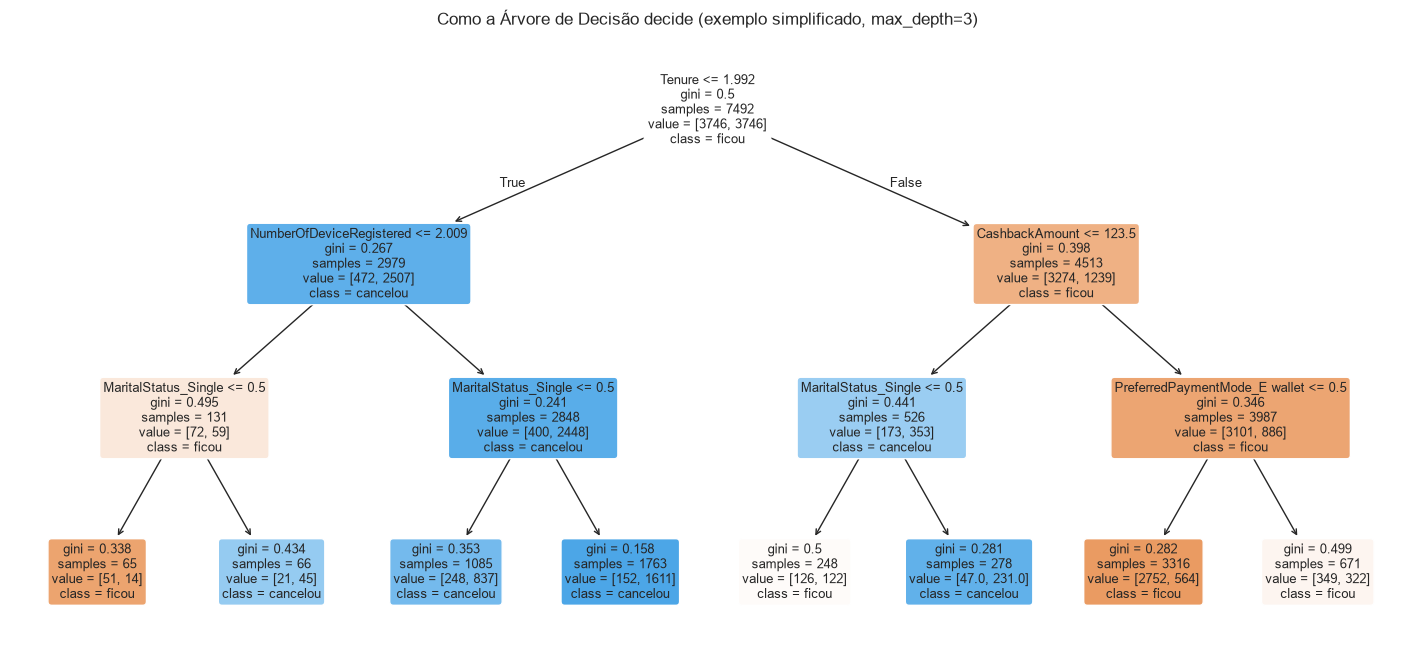

In [138]:
modelo_arvore_visual = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arvore_visual.fit(X_train_bal, y_train_bal)

plt.figure(figsize=(18, 8))
plot_tree(
    modelo_arvore_visual,
    feature_names=X_train_bal.columns,
    class_names=["ficou", "cancelou"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Como a Árvore de Decisão decide (exemplo simplificado, max_depth=3)")
plt.show()

## Diagnóstico de Overfitting ##



Para o KNN e Árvore de Decisão preferi fazer as tabelas e gráficos conforme já executado acima para testar vários hiperparâmetros e realizar a análise de forma detalhada, estruturada e embasada modelo a modelo.

No **KNN**, o gráfico inicial compara o **recall** no treino e no teste para cada K. A métrica escolhida é o recall — e não a acurácia — porque o treino foi balanceado pelo SMOTE enquanto o teste permanece desbalanceado (representa a realidade). Comparar acurácia entre bases com proporções de classe diferentes seria injusto; o recall mede diretamente o que importa: quantos churns reais o modelo consegue detectar. Dentro de todos os parâmetros os finalistas foram os K = 3 a 6.

Para evitar que a escolha de K dependesse de uma única divisão treino/teste, rodei uma **validação cruzada de 5 dobras** usando um `Pipeline(SMOTE → StandardScaler → KNN)`: o SMOTE é aplicado dentro de cada dobra, garantindo que o conjunto de validação nunca receba dados sintéticos gerados com base nele mesmo. Os resultados de recall médio e F1 médio confirmaram o **K = 3** como melhor opção entre os finalistas.

Já na **Árvore de Decisão**, a divisão única de treino/teste mostrou `max_depth=14` como "melhor" (99,4% treino vs 94,6% teste), mas isso pode ser apenas sorte nessa divisão. Por isso rodei uma **validação cruzada de 5 grupos** nas profundidades mais promissoras: `max_depth=None` teve a maior acurácia média (93,03%), mas é justamente o que decorou 100% do treino na divisão única — sinal claro de overfitting, então foi descartado.

Entre as profundidades limitadas, `max_depth=12` com 92,38% e o **menor desvio de todos (0,56%)** foi o parâmetro mais estável entre os grupos, e é nossa recomendação final.